In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Sensor Logs- Already in IST

In [45]:
logs = pd.read_json('manan_system_logs.jsonl', lines = True)

In [46]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"]).dt.tz_localize("Asia/Kolkata")

In [47]:
logs.head()     # This is in IST Format only

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuVoltageCore1,cpuAverageClock,cpuEfficiencyAverageClock,cpuFactors,virtualMemoryUsage,totalMemoryUsage,...,gpuHotspotTemperature,gpuCoreLoad,gpuCoreVoltage,gpuPackagePower,gpuCoreClock,gpuMemoryClock,gpuMemoryLoad,ssdCompositeTemperature,networkConnections,processCount
0,2026-07-13 02:06:50.885332200+05:30,37.1,66,24.1,0.82,2179.8,1461.6,[],37.0,69.3,...,57.0,0,0.89,1.2,700,8001,2.8,49,136,273
1,2026-07-13 02:06:53.658372200+05:30,5.4,62,11.5,0.82,1965.6,1108.8,[],37.3,70.6,...,57.4,0,0.89,16.7,700,6001,2.8,49,139,273
2,2026-07-13 02:06:55.855279200+05:30,7.0,65,11.9,0.71,1776.6,1108.8,[],37.2,70.6,...,57.5,0,0.89,16.2,700,7001,2.8,49,139,273
3,2026-07-13 02:06:57.915967+05:30,35.8,66,25.4,0.79,2406.6,1751.4,[],38.2,71.1,...,57.3,0,0.89,16.2,700,6001,2.8,49,140,275
4,2026-07-13 02:06:59.973184500+05:30,20.0,67,22.1,0.83,2192.4,1965.6,[],38.0,71.9,...,57.0,0,0.77,11.5,700,6001,2.8,49,140,275


# Load Stress Events - UTC Format (Z)

In [48]:
events = pd.read_json("manan_stress_events.jsonl", lines = True)

In [49]:
events["startTime"] = pd.to_datetime(events["startTime"], utc= True).dt.tz_convert("Asia/Kolkata")
events["endTime"] = pd.to_datetime(events["endTime"], utc= True).dt.tz_convert("Asia/Kolkata")


In [50]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,gpuTargetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,Manan_2026-07-12T20-37-00-905816800Z,Manan,SYSTEM,0,-1,0,2026-07-13 02:07:02.710918600+05:30,2026-07-13 02:07:02.710918600+05:30,0,201,Automatic stress experiment started.
1,SESSION,Manan_2026-07-12T20-37-00-905816800Z,Manan,INITIAL_IDLE,0,-1,0,2026-07-13 02:07:02.714923300+05:30,2026-07-13 02:09:02.716166500+05:30,120,201,Idle or cooling session completed.
2,WORKLOAD_STEP,Manan_2026-07-12T20-37-00-905816800Z,Manan,RAMP,0,-1,1,2026-07-13 02:09:02.724096300+05:30,2026-07-13 02:10:01.725820700+05:30,59,201,Completed workload step.
3,WORKLOAD_STEP,Manan_2026-07-12T20-37-00-905816800Z,Manan,RAMP,0,-1,2,2026-07-13 02:10:01.726842+05:30,2026-07-13 02:12:56.729699600+05:30,175,201,Completed workload step.
4,WORKLOAD_STEP,Manan_2026-07-12T20-37-00-905816800Z,Manan,RAMP,20,-1,3,2026-07-13 02:12:56.730703700+05:30,2026-07-13 02:14:08.733413600+05:30,72,201,Completed workload step.


In [51]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"])

events["startTime"] = pd.to_datetime(events["startTime"])
events["endTime"] = pd.to_datetime(events["endTime"])


In [52]:
logs = logs.sort_values("timestamp").reset_index(drop=True)
events = events.sort_values("startTime").reset_index(drop=True)

In [53]:
logs.head()

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuVoltageCore1,cpuAverageClock,cpuEfficiencyAverageClock,cpuFactors,virtualMemoryUsage,totalMemoryUsage,...,gpuHotspotTemperature,gpuCoreLoad,gpuCoreVoltage,gpuPackagePower,gpuCoreClock,gpuMemoryClock,gpuMemoryLoad,ssdCompositeTemperature,networkConnections,processCount
0,2026-07-13 02:06:50.885332200+05:30,37.1,66,24.1,0.82,2179.8,1461.6,[],37.0,69.3,...,57.0,0,0.89,1.2,700,8001,2.8,49,136,273
1,2026-07-13 02:06:53.658372200+05:30,5.4,62,11.5,0.82,1965.6,1108.8,[],37.3,70.6,...,57.4,0,0.89,16.7,700,6001,2.8,49,139,273
2,2026-07-13 02:06:55.855279200+05:30,7.0,65,11.9,0.71,1776.6,1108.8,[],37.2,70.6,...,57.5,0,0.89,16.2,700,7001,2.8,49,139,273
3,2026-07-13 02:06:57.915967+05:30,35.8,66,25.4,0.79,2406.6,1751.4,[],38.2,71.1,...,57.3,0,0.89,16.2,700,6001,2.8,49,140,275
4,2026-07-13 02:06:59.973184500+05:30,20.0,67,22.1,0.83,2192.4,1965.6,[],38.0,71.9,...,57.0,0,0.77,11.5,700,6001,2.8,49,140,275


In [54]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,gpuTargetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,Manan_2026-07-12T20-37-00-905816800Z,Manan,SYSTEM,0,-1,0,2026-07-13 02:07:02.710918600+05:30,2026-07-13 02:07:02.710918600+05:30,0,201,Automatic stress experiment started.
1,RUN,Manan_2026-07-12T20-37-00-905816800Z,Manan,COMPLETE_EXPERIMENT,0,-1,0,2026-07-13 02:07:02.710918600+05:30,2026-07-13 10:19:02.806670900+05:30,29520,201,Experiment completed normally.
2,SESSION,Manan_2026-07-12T20-37-00-905816800Z,Manan,INITIAL_IDLE,0,-1,0,2026-07-13 02:07:02.714923300+05:30,2026-07-13 02:09:02.716166500+05:30,120,201,Idle or cooling session completed.
3,SESSION,Manan_2026-07-12T20-37-00-905816800Z,Manan,RAMP,0,-1,50,2026-07-13 02:09:02.721065100+05:30,2026-07-13 03:23:02.723362900+05:30,4440,201,Workload session completed.
4,WORKLOAD_STEP,Manan_2026-07-12T20-37-00-905816800Z,Manan,RAMP,0,-1,1,2026-07-13 02:09:02.724096300+05:30,2026-07-13 02:10:01.725820700+05:30,59,201,Completed workload step.


In [55]:
print("Sensor start:", logs["timestamp"].min())
print("Sensor end:  ", logs["timestamp"].max())


Sensor start: 2026-07-13 02:06:50.885332200+05:30
Sensor end:   2026-07-13 10:44:23.217373300+05:30


In [56]:
print("\nEvent start:", events["startTime"].min())
print("Event end:  ", events["endTime"].max())


Event start: 2026-07-13 02:07:02.710918600+05:30
Event end:   2026-07-13 10:19:02.806670900+05:30


In [57]:
print("Sensor timezone:", logs["timestamp"].dt.tz)
print("Event timezone:", events["startTime"].dt.tz)

Sensor timezone: Asia/Kolkata
Event timezone: Asia/Kolkata


In [58]:
print(events.head(10).to_string())

print("\nUnique event types:")
if "eventType" in events.columns:
    print(events["eventType"].value_counts())

print("\nUnique modes:")
if "mode" in events.columns:
    print(events["mode"].value_counts())

       eventType                                 runId deviceId                 mode  targetLoad  gpuTargetLoad  stepNumber                           startTime                             endTime  actualDurationSeconds  seed                               message
0      RUN_START  Manan_2026-07-12T20-37-00-905816800Z    Manan               SYSTEM           0             -1           0 2026-07-13 02:07:02.710918600+05:30 2026-07-13 02:07:02.710918600+05:30                      0   201  Automatic stress experiment started.
1            RUN  Manan_2026-07-12T20-37-00-905816800Z    Manan  COMPLETE_EXPERIMENT           0             -1           0 2026-07-13 02:07:02.710918600+05:30 2026-07-13 10:19:02.806670900+05:30                  29520   201        Experiment completed normally.
2        SESSION  Manan_2026-07-12T20-37-00-905816800Z    Manan         INITIAL_IDLE           0             -1           0 2026-07-13 02:07:02.714923300+05:30 2026-07-13 02:09:02.716166500+05:30                

# Cleaning the Stress Intervals

In [59]:
# Keep events that have a valid time interval
intervals = events[
    events["startTime"].notna() &
    events["endTime"].notna()
].copy()

# Remove invalid intervals
intervals = intervals[
    intervals["endTime"] > intervals["startTime"]
].copy()
intervals = intervals.sort_values("startTime").reset_index(drop=True)
print("Usable intervals:", len(intervals))

display(
    intervals[
        [
            col for col in [
                "startTime",
                "endTime",
                "mode",
                "targetLoad",
                "stepNumber",
                "eventType"
            ]
            if col in intervals.columns
        ]
    ].head(20)
)


Usable intervals: 325


,startTime,endTime,mode,targetLoad,stepNumber,eventType
0,2026-07-13 02:07:02.710918600+05:30,2026-07-13 10:19:02.806670900+05:30,COMPLETE_EXPERIMENT,0,0,RUN
1,2026-07-13 02:07:02.714923300+05:30,2026-07-13 02:09:02.716166500+05:30,INITIAL_IDLE,0,0,SESSION
2,2026-07-13 02:09:02.721065100+05:30,2026-07-13 03:23:02.723362900+05:30,RAMP,0,50,SESSION
3,2026-07-13 02:09:02.724096300+05:30,2026-07-13 02:10:01.725820700+05:30,RAMP,0,1,WORKLOAD_STEP
4,2026-07-13 02:10:01.726842+05:30,2026-07-13 02:12:56.729699600+05:30,RAMP,0,2,WORKLOAD_STEP
5,2026-07-13 02:12:56.730703700+05:30,2026-07-13 02:14:08.733413600+05:30,RAMP,20,3,WORKLOAD_STEP
6,2026-07-13 02:14:08.734416500+05:30,2026-07-13 02:15:28.737192100+05:30,RAMP,20,4,WORKLOAD_STEP
7,2026-07-13 02:15:28.738196200+05:30,2026-07-13 02:15:48.739585500+05:30,RAMP,40,5,WORKLOAD_STEP
8,2026-07-13 02:15:48.740213700+05:30,2026-07-13 02:17:25.741474600+05:30,RAMP,40,6,WORKLOAD_STEP
9,2026-07-13 02:17:25.742453+05:30,2026-07-13 02:18:39.744110800+05:30,RAMP,60,7,WORKLOAD_STEP


In [60]:
# ============================================================
# BUILD CLEAN INTERVAL TABLES
# ============================================================

# Detailed workload intervals
workload_steps = events[
    events["eventType"] == "WORKLOAD_STEP"
].copy()

# Idle and cooling intervals
session_intervals = events[
    (events["eventType"] == "SESSION") &
    (
        (events["mode"] == "INITIAL_IDLE") |
        (events["mode"].str.contains("COOLING", na=False))
    )
].copy()


print("Workload steps:", len(workload_steps))
print("Idle/cooling sessions:", len(session_intervals))

print("\nWorkload modes:")
print(workload_steps["mode"].value_counts())

print("\nNon-workload sessions:")
print(session_intervals["mode"].value_counts())

Workload steps: 307
Idle/cooling sessions: 9

Workload modes:
mode
MIXED               97
CHAOS               57
TRANSITION          53
RAMP                50
GPU_CPU_COMBINED    50
Name: count, dtype: int64

Non-workload sessions:
mode
INITIAL_IDLE                        1
COOLING_AFTER_RAMP                  1
COOLING_AFTER_GPU_CPU_COMBINED_1    1
COOLING_AFTER_CHAOS                 1
COOLING_AFTER_GPU_CPU_COMBINED_2    1
COOLING_AFTER_TRANSITION            1
COOLING_AFTER_GPU_CPU_COMBINED_3    1
COOLING_AFTER_MIXED                 1
FINAL_COOLING                       1
Name: count, dtype: int64


In [61]:
import numpy as np

In [62]:
merged = logs.copy()

merged["mode"] = "UNASSIGNED"
merged["targetLoad"] = np.nan
merged["gpuTargetLoad"] = np.nan
merged["stepNumber"] = np.nan
merged["eventType"] = None


# ===============
# =============================================
# 1. ASSIGN IDLE AND COOLING SESSIONS
# ============================================================

for _, event in session_intervals.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = 0
    merged.loc[mask, "gpuTargetLoad"] = np.nan
    merged.loc[mask, "eventType"] = "SESSION"


# ============================================================
# 2. ASSIGN ACTUAL WORKLOAD STEPS
# ============================================================

for _, event in workload_steps.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = event["targetLoad"]
    merged.loc[mask, "gpuTargetLoad"] = event["gpuTargetLoad"]
    merged.loc[mask, "stepNumber"] = event["stepNumber"]
    merged.loc[mask, "eventType"] = "WORKLOAD_STEP"


# ============================================================
# 3. IMPUTE ZERO TEMPERATURE READINGS
# ============================================================

zero_temp_mask = merged["cpuTemperature"] == 0
zero_temp_count = int(zero_temp_mask.sum())

if zero_temp_count > 0:
    merged.loc[zero_temp_mask, "cpuTemperature"] = np.nan
    merged["cpuTemperature"] = (
        merged["cpuTemperature"]
        .interpolate(method="linear")
        .ffill()
        .bfill()
    )
    print(f"Imputed {zero_temp_count} zero-temperature rows.")


In [63]:
print("Merged shape:", merged.shape)

print("\nMode distribution:")
print(merged["mode"].value_counts())

print("\nEvent type distribution:")
print(merged["eventType"].value_counts(dropna=False))

print("\nUnassigned samples:")
print((merged["mode"] == "UNASSIGNED").sum())

Merged shape: (15275, 28)

Mode distribution:
mode
MIXED                               4365
GPU_CPU_COMBINED                    2214
CHAOS                               2188
TRANSITION                          2185
RAMP                                2183
UNASSIGNED                           757
FINAL_COOLING                        294
COOLING_AFTER_CHAOS                  148
COOLING_AFTER_MIXED                  148
COOLING_AFTER_RAMP                   147
COOLING_AFTER_GPU_CPU_COMBINED_1     147
COOLING_AFTER_GPU_CPU_COMBINED_2     147
COOLING_AFTER_TRANSITION             147
COOLING_AFTER_GPU_CPU_COMBINED_3     147
INITIAL_IDLE                          58
Name: count, dtype: int64

Event type distribution:
eventType
WORKLOAD_STEP    13135
SESSION           1383
None               757
Name: count, dtype: int64

Unassigned samples:
757


In [64]:
# experiment_start = events.loc[
#     events["eventType"] == "RUN",
#     "startTime"
# ].iloc[0]

# experiment_end = events.loc[
#     events["eventType"] == "RUN",
#     "endTime"
# ].iloc[0]


# merged.loc[
#     merged["timestamp"] < experiment_start,
#     "mode"
# ] = "PRE_EXPERIMENT"


# merged.loc[
#     merged["timestamp"] >= experiment_end,
#     "mode"
# ] = "POST_EXPERIMENT"

In [65]:
merged.to_csv(
    "manan_merged_experiment.csv",
    index=False
)

print("Saved: manan_merged_experiment.csv")

Saved: manan_merged_experiment.csv


In [66]:
import matplotlib.pyplot as plt

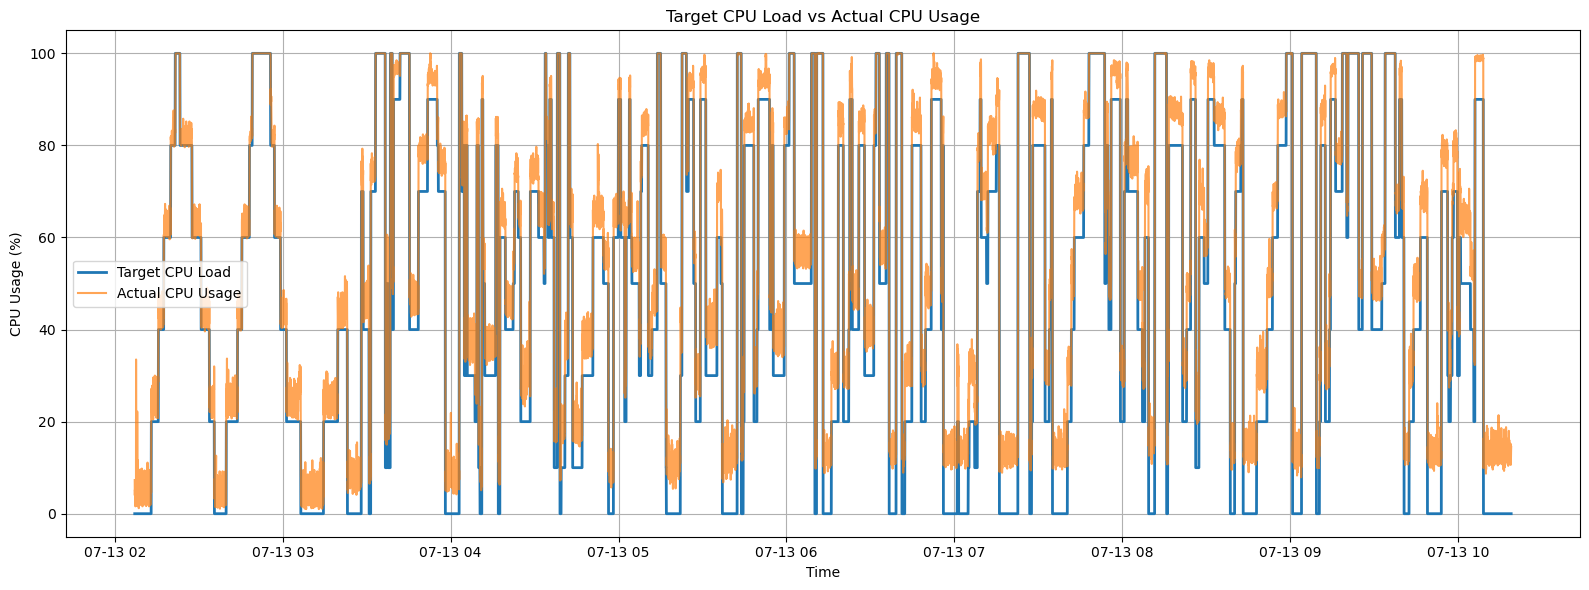

In [67]:
valid_target = merged.dropna(
    subset=["targetLoad", "cpuUsage"]
).copy()

plt.figure(figsize=(16, 6))

plt.plot(
    valid_target["timestamp"],
    valid_target["targetLoad"],
    label="Target CPU Load",
    linewidth=2
)

plt.plot(
    valid_target["timestamp"],
    valid_target["cpuUsage"],
    label="Actual CPU Usage",
    alpha=0.7
)

plt.title("Target CPU Load vs Actual CPU Usage")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [68]:
valid_target["loadError"] = (
    valid_target["cpuUsage"] -
    valid_target["targetLoad"]
)

print(
    "Mean Absolute Load Error:",
    valid_target["loadError"].abs().mean()
)

print(
    "Correlation:",
    valid_target[
        ["targetLoad", "cpuUsage"]
    ].corr().iloc[0, 1]
)

Mean Absolute Load Error: 7.472434219589474
Correlation: 0.9861262791620349


In [69]:
load_summary = (
    valid_target
    .groupby("targetLoad")
    .agg(
        samples=("cpuUsage", "count"),
        meanActualCPU=("cpuUsage", "mean"),
        stdActualCPU=("cpuUsage", "std"),
        meanTemperature=("cpuTemperature", "mean")
    )
    .reset_index()
)

display(load_summary)

,targetLoad,samples,meanActualCPU,stdActualCPU,meanTemperature
0,0.0,3005,11.634343,5.905058,61.422629
1,10.0,309,21.309061,7.141114,63.090615
2,20.0,1562,29.057682,4.772055,67.980794
3,30.0,820,38.928780,4.134426,76.410976
4,40.0,1401,47.620128,4.989308,81.831549
5,50.0,747,58.363588,4.434614,87.583668
6,60.0,1320,66.212727,4.697991,89.373485
7,70.0,889,77.071091,4.831746,93.003375
8,80.0,1472,85.365082,4.409581,94.936141
9,90.0,1040,95.136058,4.946810,96.176923


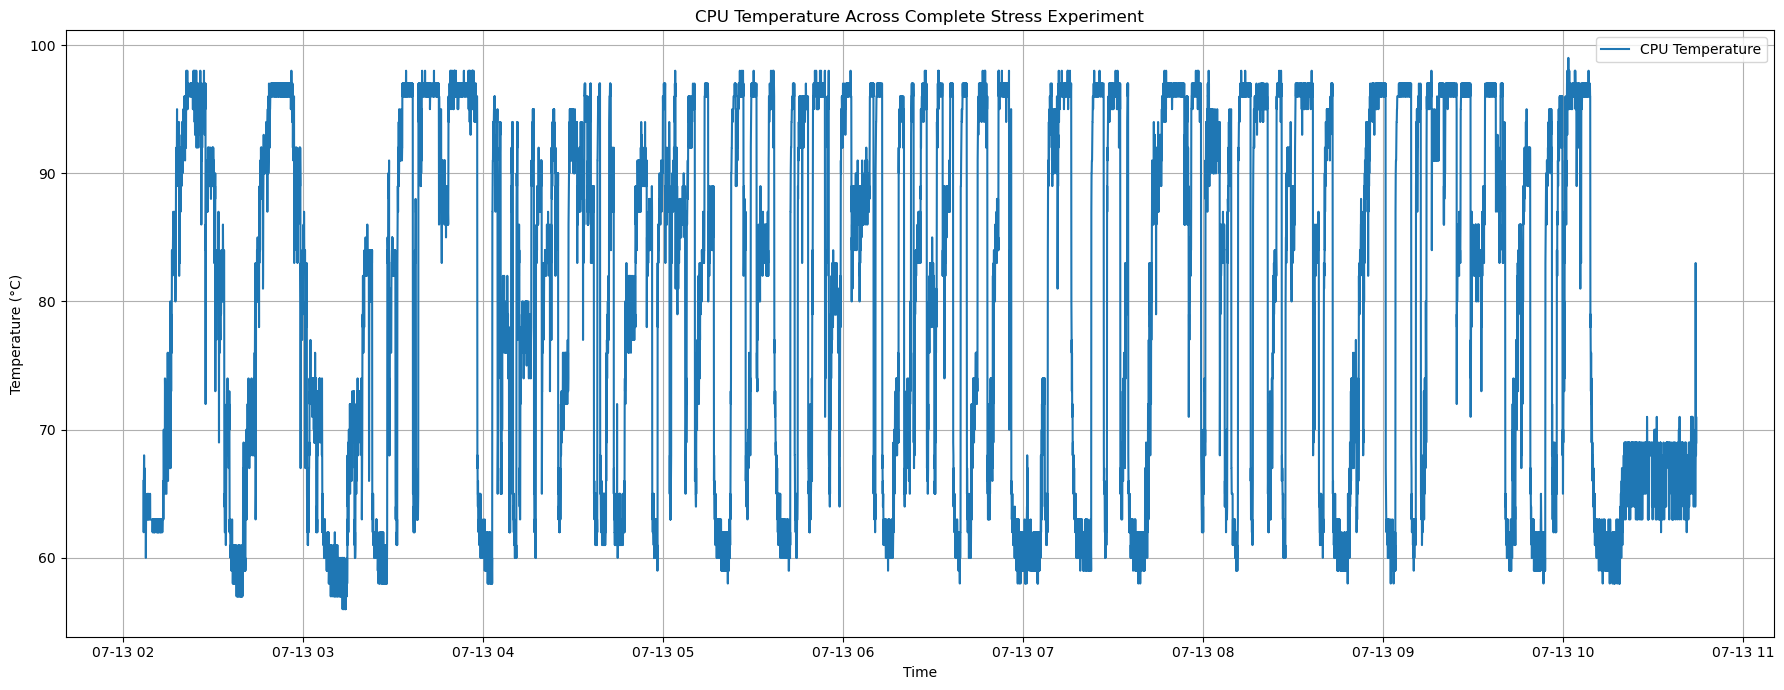

In [70]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

plt.title(
    "CPU Temperature Across Complete Stress Experiment"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
mode_changes = merged[
    merged["mode"] != merged["mode"].shift()
][
    ["timestamp", "mode"]
]

display(mode_changes)

,timestamp,mode
0,2026-07-13 02:06:50.885332200+05:30,UNASSIGNED
6,2026-07-13 02:07:04.078778100+05:30,INITIAL_IDLE
64,2026-07-13 02:09:03.184592700+05:30,RAMP
804,2026-07-13 02:34:07.779023400+05:30,UNASSIGNED
805,2026-07-13 02:34:09.817656200+05:30,RAMP
2248,2026-07-13 03:23:03.436974100+05:30,COOLING_AFTER_RAMP
2395,2026-07-13 03:28:02.811382100+05:30,GPU_CPU_COMBINED
3279,2026-07-13 03:58:03.432144900+05:30,COOLING_AFTER_GPU_CPU_COMBINED_1
3426,2026-07-13 04:03:02.793828900+05:30,CHAOS
5614,2026-07-13 05:17:02.984345100+05:30,COOLING_AFTER_CHAOS


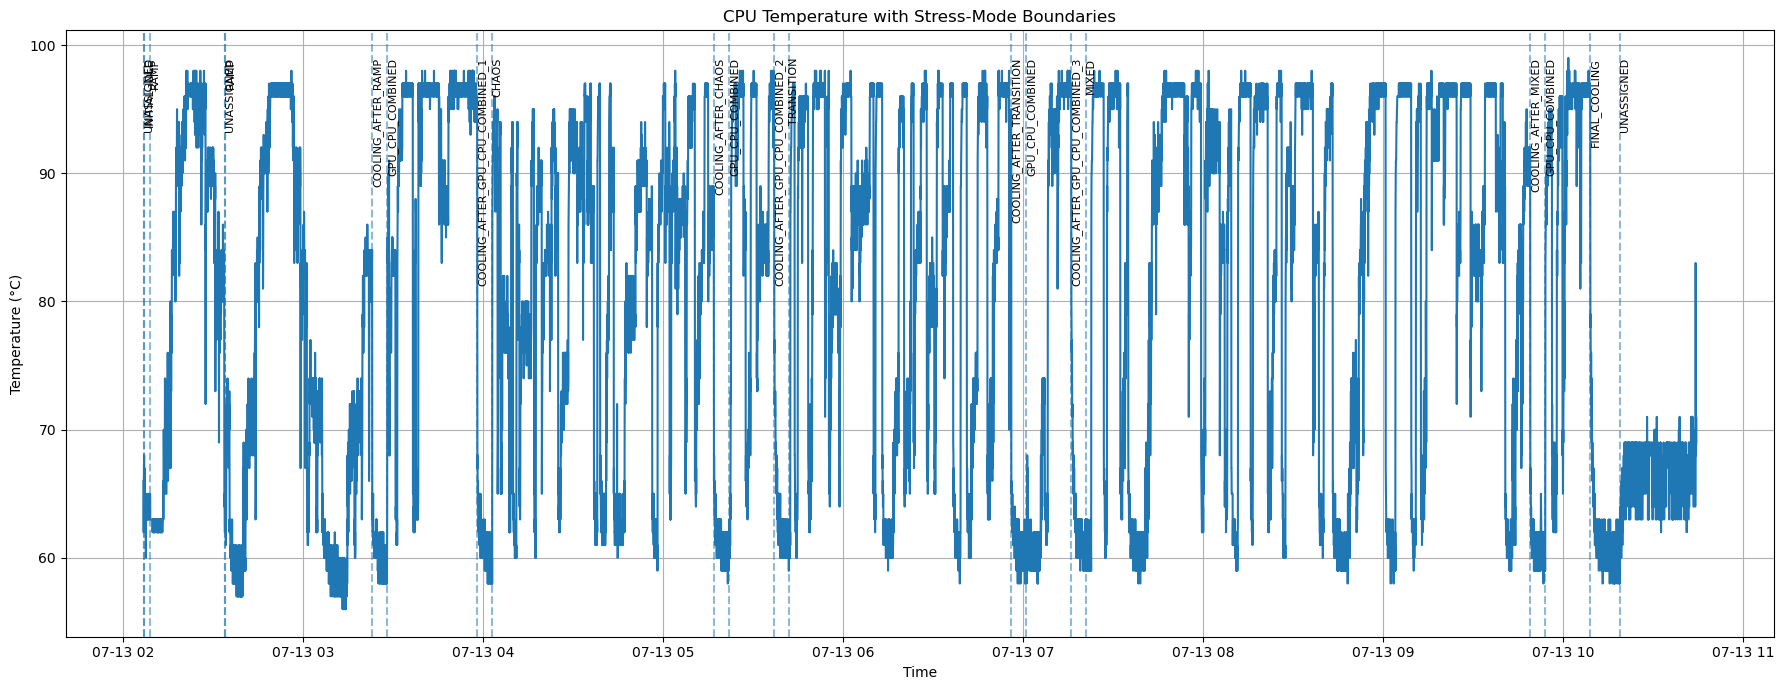

In [72]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

for _, row in mode_changes.iterrows():

    plt.axvline(
        row["timestamp"],
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        row["timestamp"],
        merged["cpuTemperature"].max(),
        str(row["mode"]),
        rotation=90,
        verticalalignment="top",
        fontsize=8
    )

plt.title(
    "CPU Temperature with Stress-Mode Boundaries"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [73]:
# Correlate every numeric sensor and workload target with both temperatures.
# Pearson captures linear relationships; Spearman captures monotonic ones.
temperature_targets = ["cpuTemperature", "gpuTemperature"]
numeric_features = merged.select_dtypes(include="number").columns.tolist()
feature_columns = [
    col for col in numeric_features
    if col not in temperature_targets + ["stepNumber"]
]

pearson_correlations = merged[feature_columns + temperature_targets].corr(method="pearson")
spearman_correlations = merged[feature_columns + temperature_targets].corr(method="spearman")

correlation_summary = (
    pd.DataFrame({
        "pearson_cpuTemperature": pearson_correlations["cpuTemperature"].drop("cpuTemperature"),
        "spearman_cpuTemperature": spearman_correlations["cpuTemperature"].drop("cpuTemperature"),
        "pearson_gpuTemperature": pearson_correlations["gpuTemperature"].drop("gpuTemperature"),
        "spearman_gpuTemperature": spearman_correlations["gpuTemperature"].drop("gpuTemperature"),
    })
    .drop(index=["gpuTemperature", "cpuTemperature"], errors="ignore")
)
correlation_summary["max_abs_pearson"] = correlation_summary[
    ["pearson_cpuTemperature", "pearson_gpuTemperature"]
].abs().max(axis=1)
correlation_summary = correlation_summary.sort_values("max_abs_pearson", ascending=False)

display(correlation_summary.round(3))

# Dedicated efficiency-clock correlations requested for CPU frequency analysis.
efficiency_clock_pairs = [
    ("cpuEfficiencyAverageClock", "cpuAverageClock", "Average CPU Clock"),
    ("cpuEfficiencyAverageClock", "cpuVoltageCore1", "CPU Core 1 Voltage"),
]
efficiency_clock_correlation = pd.DataFrame([
    {
        "feature": label,
        "pearsonCorrelation": merged[[efficiency_col, feature_col]].corr(method="pearson").iloc[0, 1],
        "spearmanCorrelation": merged[[efficiency_col, feature_col]].corr(method="spearman").iloc[0, 1],
    }
    for efficiency_col, feature_col, label in efficiency_clock_pairs
])
display(efficiency_clock_correlation.round(3))


,pearson_cpuTemperature,spearman_cpuTemperature,pearson_gpuTemperature,spearman_gpuTemperature,max_abs_pearson
gpuCoreTemperature,0.429,0.756,1.000,1.000,1.000
gpuHotspotTemperature,0.419,0.800,0.997,0.978,0.997
cpuPackagePower,0.967,0.919,0.286,0.616,0.967
cpuUsage,0.947,0.939,0.355,0.634,0.947
gpuCoreLoad,0.271,0.274,0.941,0.456,0.941
targetLoad,0.939,0.939,0.347,0.761,0.939
cpuEfficiencyAverageClock,0.936,0.867,0.278,0.600,0.936
gpuTargetLoad,0.245,0.202,0.854,0.422,0.854
cpuAverageClock,0.845,0.674,0.223,0.444,0.845
cpuVoltageCore1,0.718,0.449,0.138,0.297,0.718


,feature,pearsonCorrelation,spearmanCorrelation
0,Average CPU Clock,0.823,0.770
1,CPU Core 1 Voltage,0.718,0.536


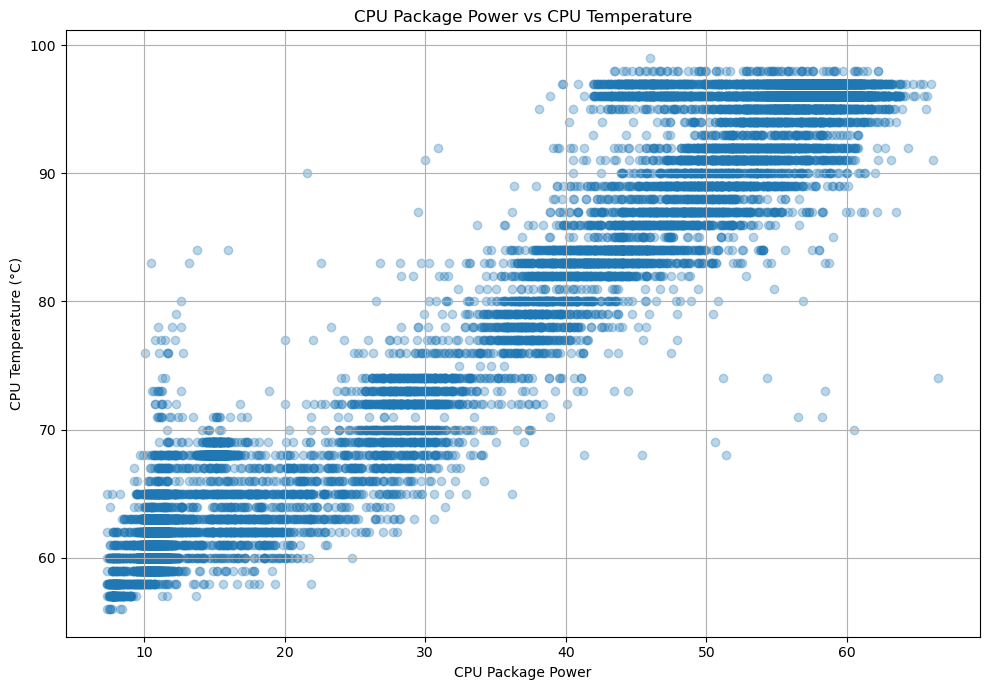

In [75]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuPackagePower"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Package Power vs CPU Temperature")
plt.xlabel("CPU Package Power")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

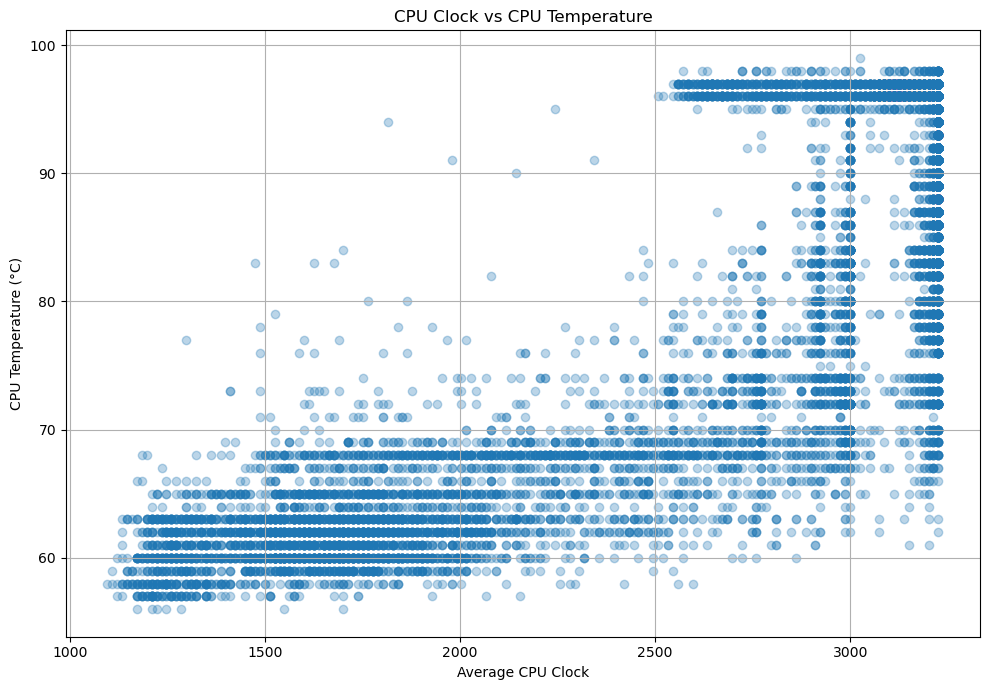

In [76]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuAverageClock"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Clock vs CPU Temperature")
plt.xlabel("Average CPU Clock")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

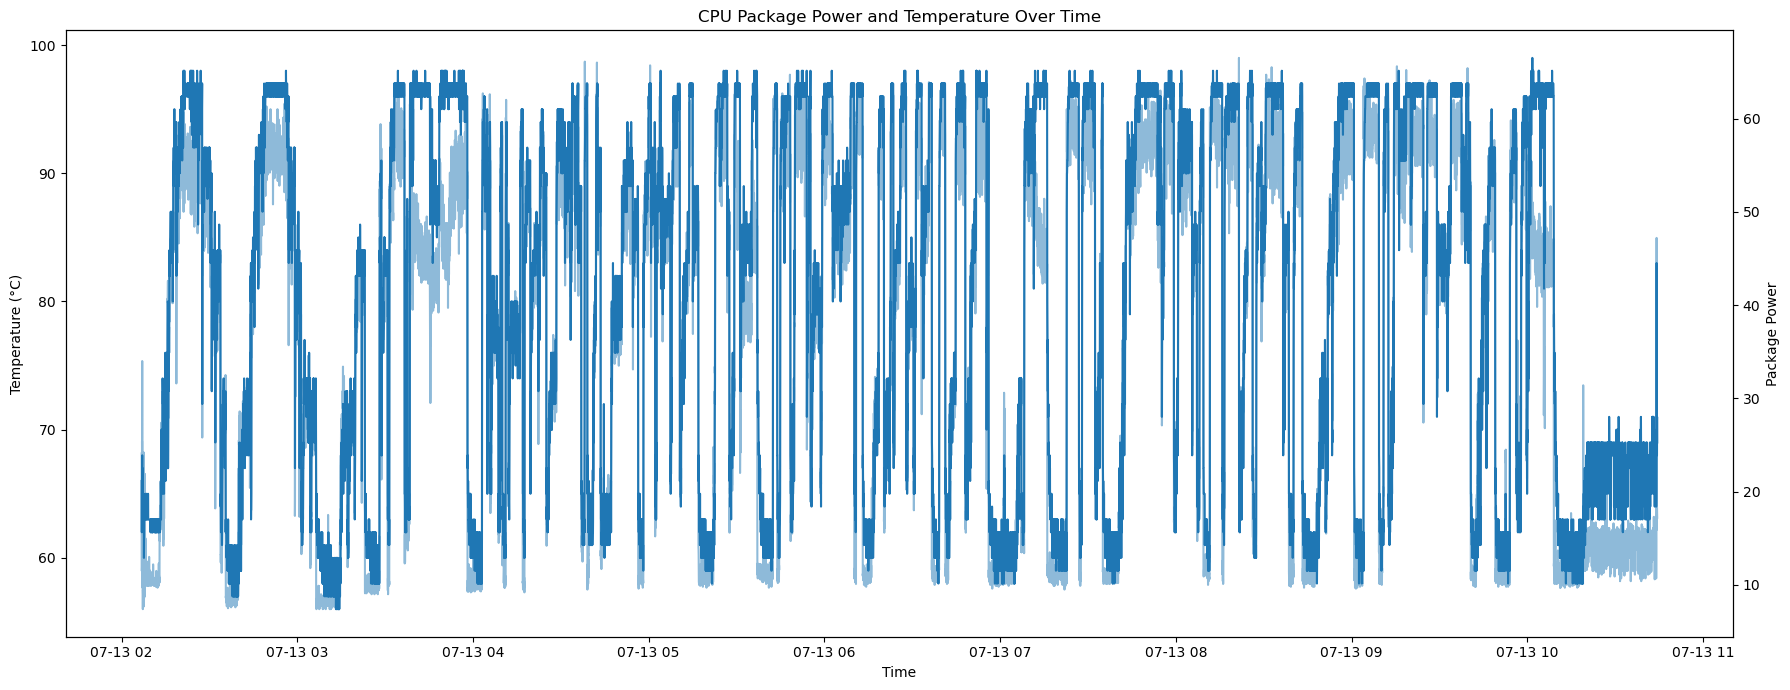

In [77]:
fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="Temperature"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    merged["timestamp"],
    merged["cpuPackagePower"],
    alpha=0.5,
    label="Package Power"
)

ax2.set_ylabel("Package Power")

plt.title(
    "CPU Package Power and Temperature Over Time"
)

fig.tight_layout()
plt.show()

In [78]:
cooling = merged[
    merged["mode"]
    .astype(str)
    .str.contains("COOLING", case=False, na=False)
].copy()

print("Cooling samples:", len(cooling))

print(
    cooling["mode"].value_counts()
)

Cooling samples: 1325
mode
FINAL_COOLING                       294
COOLING_AFTER_CHAOS                 148
COOLING_AFTER_MIXED                 148
COOLING_AFTER_RAMP                  147
COOLING_AFTER_GPU_CPU_COMBINED_1    147
COOLING_AFTER_GPU_CPU_COMBINED_2    147
COOLING_AFTER_TRANSITION            147
COOLING_AFTER_GPU_CPU_COMBINED_3    147
Name: count, dtype: int64


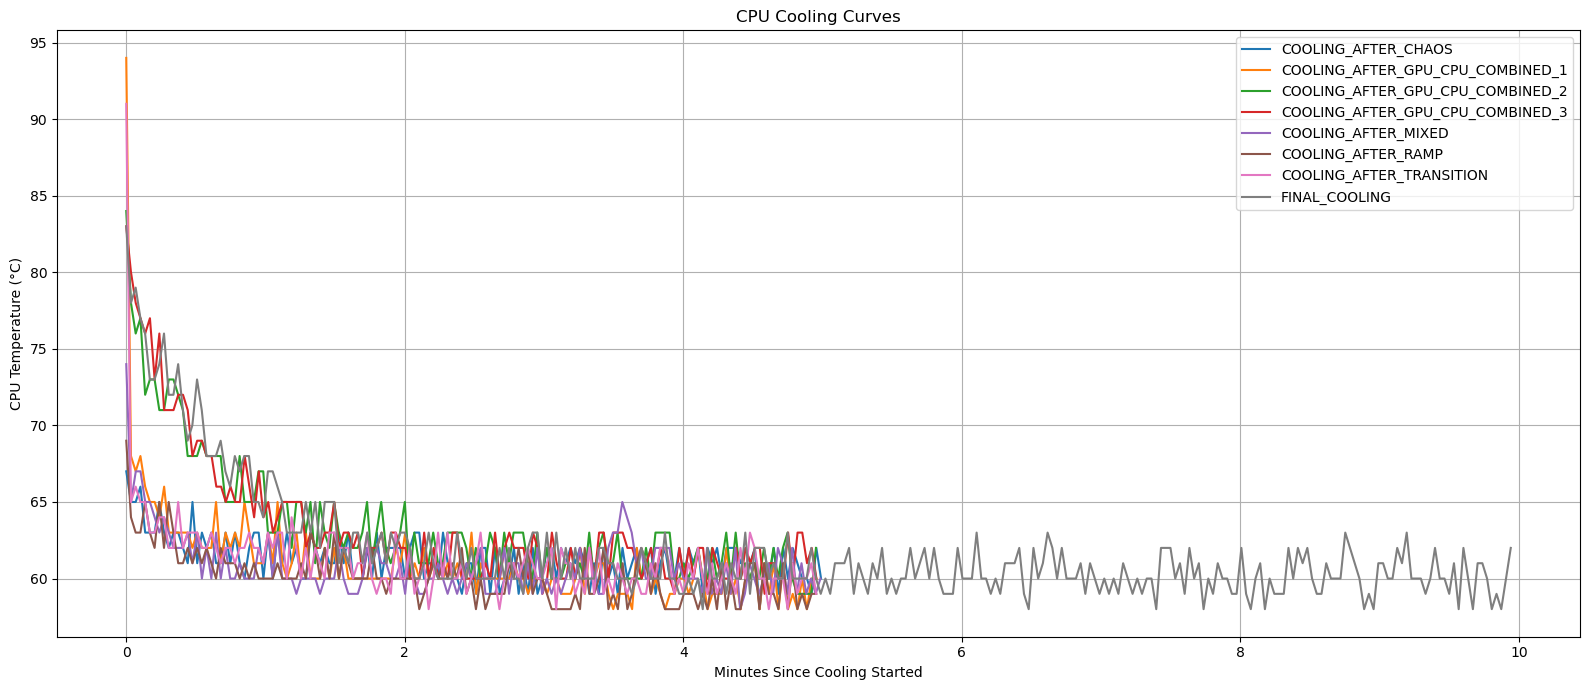

In [79]:
plt.figure(figsize=(16, 7))

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp").copy()

    elapsed_minutes = (
        group["timestamp"] -
        group["timestamp"].min()
    ).dt.total_seconds() / 60

    plt.plot(
        elapsed_minutes,
        group["cpuTemperature"],
        label=mode
    )

plt.title("CPU Cooling Curves")
plt.xlabel("Minutes Since Cooling Started")
plt.ylabel("CPU Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [80]:
cooling_summary = []

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp")

    start_temp = group["cpuTemperature"].iloc[0]
    end_temp = group["cpuTemperature"].iloc[-1]

    duration_minutes = (
        group["timestamp"].iloc[-1] -
        group["timestamp"].iloc[0]
    ).total_seconds() / 60

    temperature_drop = (
        start_temp - end_temp
    )

    cooling_rate = (
        temperature_drop / duration_minutes
        if duration_minutes > 0
        else np.nan
    )

    cooling_summary.append({
        "mode": mode,
        "startTemperature": start_temp,
        "endTemperature": end_temp,
        "temperatureDrop": temperature_drop,
        "durationMinutes": duration_minutes,
        "coolingRatePerMinute": cooling_rate
    })

cooling_summary = pd.DataFrame(
    cooling_summary
)

display(cooling_summary)

,mode,startTemperature,endTemperature,temperatureDrop,durationMinutes,coolingRatePerMinute
0,COOLING_AFTER_CHAOS,67,60,7,4.989172,1.403038
1,COOLING_AFTER_GPU_CPU_COMBINED_1,94,60,34,4.955151,6.861546
2,COOLING_AFTER_GPU_CPU_COMBINED_2,84,62,22,4.952694,4.442027
3,COOLING_AFTER_GPU_CPU_COMBINED_3,83,60,23,4.956074,4.640770
4,COOLING_AFTER_MIXED,74,60,14,4.984617,2.808641
5,COOLING_AFTER_RAMP,69,59,10,4.955195,2.018084
6,COOLING_AFTER_TRANSITION,91,59,32,4.953823,6.459658
7,FINAL_COOLING,83,62,21,9.941934,2.112265


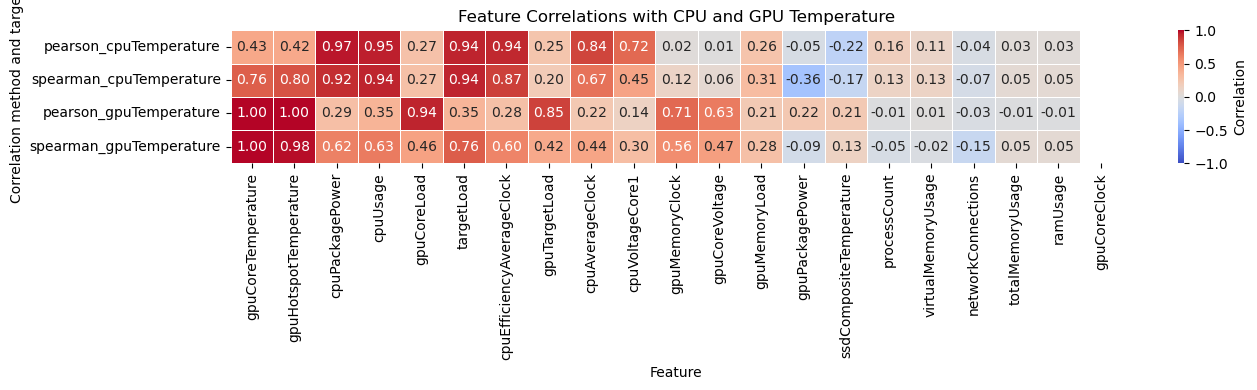

In [81]:
# Heatmap of all numeric features against CPU and GPU temperature.
heatmap_data = correlation_summary.drop(columns="max_abs_pearson").T
plt.figure(figsize=(max(12, len(heatmap_data.columns) * 0.65), 4))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.4, cbar_kws={"label": "Correlation"})
plt.title("Feature Correlations with CPU and GPU Temperature")
plt.xlabel("Feature")
plt.ylabel("Correlation method and target")
plt.tight_layout()
plt.show()

In [82]:
# Sort by time
df = merged.sort_values("timestamp").reset_index(drop=True).copy()

# Your data is sampled roughly every 2 seconds
# 20 seconds ≈ 10 rows ahead
HORIZON_STEPS = 10

# Temperature 20 seconds into the future
df["futureTemperature"] = df["cpuTemperature"].shift(-HORIZON_STEPS)

# Exact target used conceptually by your model
df["delta_t"] = (
    df["futureTemperature"] - df["cpuTemperature"]
)

# Remove final rows where future temperature is unavailable
delta_df = df.dropna(subset=["delta_t"]).copy()

print("========== MANAN DELTA T ANALYSIS ==========")
print(delta_df["delta_t"].describe())

print("\nPercentage |Delta T| <= 1°C:")
print((delta_df["delta_t"].abs() <= 1).mean() * 100, "%")

print("\nPercentage Delta T == 0°C:")
print((delta_df["delta_t"] == 0).mean() * 100, "%")

print("\nPercentage Delta T > 4°C:")
print((delta_df["delta_t"] > 4).mean() * 100, "%")

print("\nMost common Delta T values:")
print(delta_df["delta_t"].value_counts().head(15))

========== MANAN DELTA T ANALYSIS ==========
count    15265.000000
mean         0.002817
std          7.435312
min        -35.000000
25%         -1.000000
50%          0.000000
75%          2.000000
max         36.000000
Name: delta_t, dtype: float64

Percentage |Delta T| <= 1°C:
52.83327874222077 %

Percentage Delta T == 0°C:
24.461185718964952 %

Percentage Delta T > 4°C:
11.261054700294792 %

Most common Delta T values:
delta_t
 0.0    3734
 1.0    2266
-1.0    2065
 2.0    1095
-2.0     937
 3.0     727
-3.0     613
 4.0     479
 5.0     328
-4.0     275
 6.0     230
-5.0     180
 7.0     150
 8.0     132
-6.0     116
Name: count, dtype: int64


In [83]:
mode_analysis = (
    delta_df
    .groupby("mode")["delta_t"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .sort_values("count", ascending=False)
)

display(mode_analysis)

,count,mean,median,std,min,max
mode,,,,,,
MIXED,4365,0.011913,0.0,7.907308,-35.0,33.0
GPU_CPU_COMBINED,2214,0.021229,0.0,7.630770,-34.0,34.0
CHAOS,2188,-0.099634,0.0,8.982742,-35.0,36.0
TRANSITION,2185,0.027918,0.0,9.293133,-34.0,32.0
RAMP,2183,0.001374,0.0,4.459565,-25.0,19.0
UNASSIGNED,747,0.080321,0.0,2.559004,-7.0,15.0
FINAL_COOLING,294,-0.414966,0.0,2.301042,-11.0,7.0
COOLING_AFTER_CHAOS,148,-0.175676,0.0,1.835835,-5.0,4.0
COOLING_AFTER_MIXED,148,1.391892,0.0,7.051449,-12.0,31.0


In [84]:
for mode, group in delta_df.groupby("mode"):

    if len(group) < 10:
        continue

    print(f"\n========== {mode} ==========")
    print("Samples:", len(group))
    print("Mean Delta T:", group["delta_t"].mean())
    print("Median Delta T:", group["delta_t"].median())

    print(
        "% |Delta T| <= 1°C:",
        (group["delta_t"].abs() <= 1).mean() * 100
    )

    print(
        "% Delta T > 4°C:",
        (group["delta_t"] > 4).mean() * 100
    )


========== CHAOS ==========
Samples: 2188
Mean Delta T: -0.09963436928702012
Median Delta T: 0.0
% |Delta T| <= 1°C: 38.482632541133455
% Delta T > 4°C: 16.316270566727606

========== COOLING_AFTER_CHAOS ==========
Samples: 148
Mean Delta T: -0.17567567567567569
Median Delta T: 0.0
% |Delta T| <= 1°C: 53.37837837837838
% Delta T > 4°C: 0.0

========== COOLING_AFTER_GPU_CPU_COMBINED_1 ==========
Samples: 147
Mean Delta T: 1.183673469387755
Median Delta T: 0.0
% |Delta T| <= 1°C: 60.544217687074834
% Delta T > 4°C: 6.122448979591836

========== COOLING_AFTER_GPU_CPU_COMBINED_2 ==========
Samples: 147
Mean Delta T: -0.9591836734693877
Median Delta T: -1.0
% |Delta T| <= 1°C: 47.61904761904761
% Delta T > 4°C: 0.0

========== COOLING_AFTER_GPU_CPU_COMBINED_3 ==========
Samples: 147
Mean Delta T: -1.0680272108843538
Median Delta T: -1.0
% |Delta T| <= 1°C: 48.97959183673469
% Delta T > 4°C: 0.0

========== COOLING_AFTER_MIXED ==========
Samples: 148
Mean Delta T: 1.3918918918918919
Median 

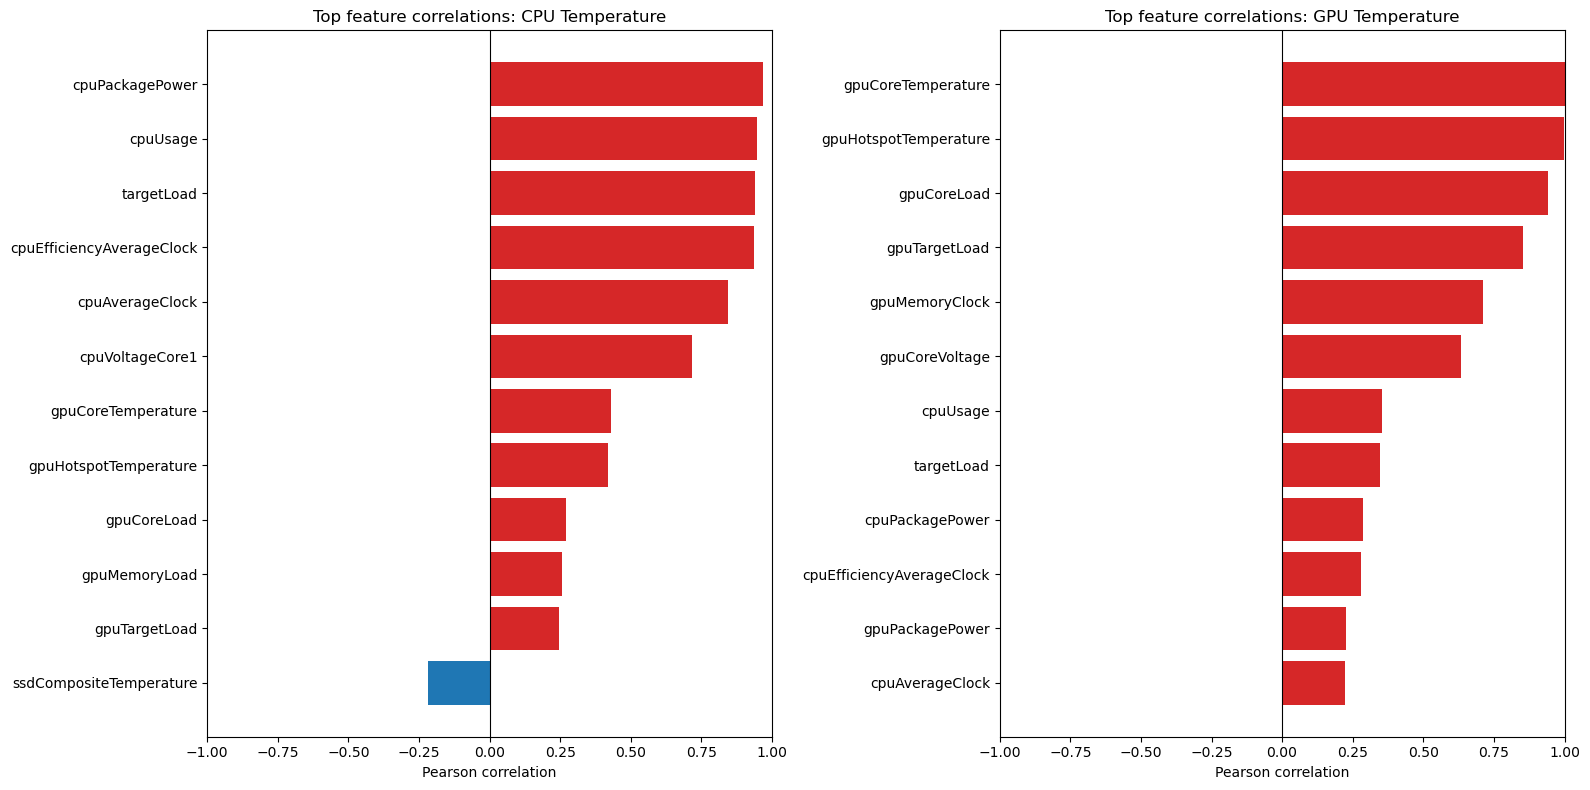

In [85]:
# Rank the strongest Pearson relationships for each temperature target.
ranked = correlation_summary.drop(columns="max_abs_pearson").copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

for ax, column, title in [
    (axes[0], "pearson_cpuTemperature", "CPU Temperature"),
    (axes[1], "pearson_gpuTemperature", "GPU Temperature"),
]:
    values = ranked[column].dropna().sort_values(key=lambda x: x.abs()).tail(12)
    colors = np.where(values >= 0, "tab:red", "tab:blue")
    ax.barh(values.index, values.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(f"Top feature correlations: {title}")
    ax.set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

GPU_CPU_COMBINED workload samples: 2214


,cpuTemperature,gpuTemperature
targetLoad,0.848,0.377
gpuTargetLoad,0.573,0.842
cpuUsage,0.870,0.433
cpuPackagePower,0.908,0.259
gpuCoreLoad,0.531,0.970
gpuPackagePower,0.478,0.984
gpuCoreClock,NaN,NaN
gpuMemoryLoad,0.239,0.345


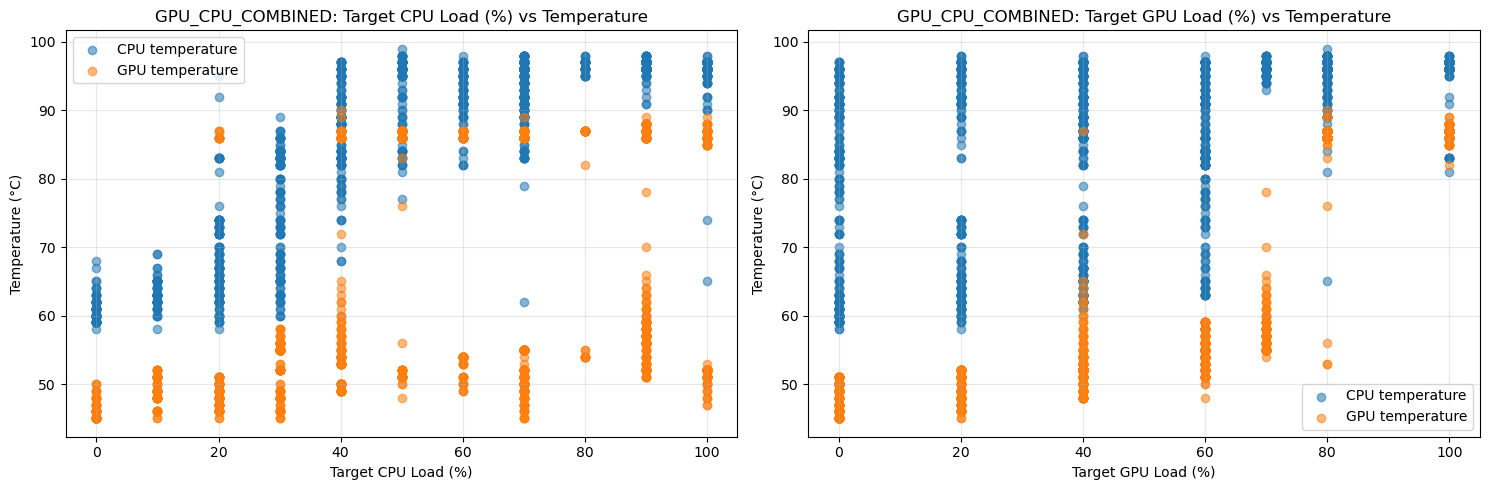

In [43]:
# GPU_CPU_COMBINED is analysed separately because gpuTargetLoad is only set there.
gpu_cpu_combined = merged[
    (merged["mode"] == "GPU_CPU_COMBINED") &
    (merged["eventType"] == "WORKLOAD_STEP")
].copy()

combined_features = [
    "targetLoad", "gpuTargetLoad", "cpuUsage", "cpuPackagePower",
    "gpuCoreLoad", "gpuPackagePower", "gpuCoreClock", "gpuMemoryLoad"
]
combined_features = [col for col in combined_features if col in gpu_cpu_combined]
combined_correlation = gpu_cpu_combined[
    combined_features + temperature_targets
].corr(method="pearson").loc[combined_features, temperature_targets]

print(f"GPU_CPU_COMBINED workload samples: {len(gpu_cpu_combined)}")
display(combined_correlation.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, x_col, x_label in [
    (axes[0], "targetLoad", "Target CPU Load (%)"),
    (axes[1], "gpuTargetLoad", "Target GPU Load (%)"),
]:
    scatter_data = gpu_cpu_combined.dropna(subset=[x_col])
    ax.scatter(scatter_data[x_col], scatter_data["cpuTemperature"], alpha=0.55,
               label="CPU temperature")
    ax.scatter(scatter_data[x_col], scatter_data["gpuTemperature"], alpha=0.55,
               label="GPU temperature")
    ax.set_title(f"GPU_CPU_COMBINED: {x_label} vs Temperature")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation quantifies association, not causation; interpret it with the
# workload mode and the time-series plots above.